In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

sns.set_style('whitegrid')

df = pd.read_csv('Data/clean_data.csv')
print(df.shape)

(16266, 54)


In [13]:
# دول الأعمدة اللي فعلياً بتتحسب منها الـ Overall في اللعبة - المستخدم هيقدر يدخلها بسهولة
overall_features = [
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
    'attacking_short_passing', 'attacking_volleys',
    'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance',
    'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
    'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision',
    'mentality_penalties', 'mentality_composure',
    'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle'
]

X1 = df[overall_features]
y1 = df['overall']

print("X1 shape:", X1.shape)

X1 shape: (16266, 35)


In [14]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

overall_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
overall_model.fit(X1_train, y1_train)

y1_pred = overall_model.predict(X1_test)

print("=== Overall Model Results ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y1_test, y1_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y1_test, y1_pred):.4f}")
print(f"R²: {r2_score(y1_test, y1_pred):.4f}")

=== Overall Model Results ===
RMSE: 1.1087
MAE: 0.8346
R²: 0.9744


In [15]:
df['predicted_overall'] = overall_model.predict(X1)

In [16]:
value_features = [
    'predicted_overall', 'potential', 'age', 'height_cm', 'weight_kg',
    'league_level', 'weak_foot', 'skill_moves', 'international_reputation',
    'years_at_club', 'contract_years_remaining', 'is_loaned',
    'nationality_freq', 'league_freq', 'preferred_foot_Right',
    'position_group_DEF', 'position_group_MID'
]

X2 = df[value_features]
y2 = np.log1p(df['value_eur'])   # log transform للـ target

print("X2 shape:", X2.shape)

X2 shape: (16266, 17)


In [17]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Baseline
lr_model = LinearRegression()
lr_model.fit(X2_train, y2_train)
y2_pred_lr = lr_model.predict(X2_test)

# Random Forest
value_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
value_model.fit(X2_train, y2_train)
y2_pred_rf = value_model.predict(X2_test)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [np.sqrt(mean_squared_error(y2_test, y2_pred_lr)), np.sqrt(mean_squared_error(y2_test, y2_pred_rf))],
    'MAE': [mean_absolute_error(y2_test, y2_pred_lr), mean_absolute_error(y2_test, y2_pred_rf)],
    'R2': [r2_score(y2_test, y2_pred_lr), r2_score(y2_test, y2_pred_rf)]
})
results

,Model,RMSE,MAE,R2
0,Linear Regression,0.624434,0.250659,0.798245
1,Random Forest,0.307951,0.110599,0.950930


C:\Users\ENG_ALI_WENINY\AppData\Local\Temp\ipykernel_34888\2050883808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


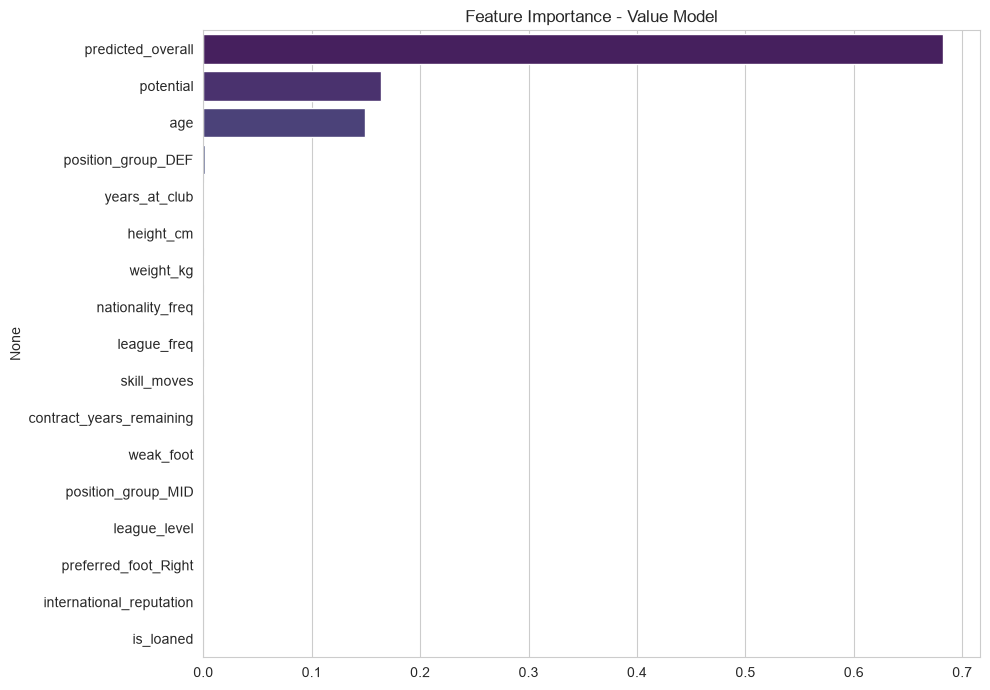

predicted_overall           0.682226
potential                   0.164250
age                         0.149574
position_group_DEF          0.001304
years_at_club               0.000453
height_cm                   0.000395
weight_kg                   0.000356
nationality_freq            0.000319
league_freq                 0.000318
skill_moves                 0.000303
contract_years_remaining    0.000155
weak_foot                   0.000124
position_group_MID          0.000092
league_level                0.000044
preferred_foot_Right        0.000044
international_reputation    0.000025
is_loaned                   0.000018
dtype: float64

In [18]:
importances = pd.Series(value_model.feature_importances_, index=X2.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance - Value Model')
plt.tight_layout()
plt.show()

importances

In [21]:
os.makedirs('models', exist_ok=True)

joblib.dump(overall_model, 'models/overall_model.pkl')
joblib.dump(overall_features, 'models/overall_features.pkl')

joblib.dump(value_model, 'models/value_model.pkl')
joblib.dump(value_features, 'models/value_features.pkl')

print("تم حفظ الموديلين بنجاح")

تم حفظ الموديلين بنجاح
